# Weekly points: between-player vs within-player variation

**Before any stat: how much of week-to-week `total_points` variation sits _between_ players vs _within_ a player?**

_Read-only diagnostic — Rung 2, association only (no predictive claim)._
Population: `minutes > 0`, **DGW excluded**, per position, whole season, players with **≥ 10 games**.

This is the **points-only descriptive preamble** to the identity-vs-state work — no signals enter. It describes how much weekly movement was observed within players this season: where within-player variation is small, a per-signal split has little within-player movement to track. It is the descriptive split that the per-signal work (`identity_vs_state.ipynb`) sits against — a description of the observed spread, not a bound on true skill.

## Setup & how to read

**Plain:** split the *observed* spread in weekly points two ways — differences *between* players (some simply score more) and a single player's swings *within* his own season (hot and cold weeks). A larger within-player share means more week-to-week movement was observed for that position.

> *In data terms:* `decompose_variance(total_points)` per position → between- vs within-player sum-of-squares share, restricted to players with ≥ 10 games (the same floor the per-signal split uses).

**Glossary**
- **between-player (identity)** — share of variation from players differing in level.
- **within-player (state)** — share of variation from a player swinging week to week. Note this still includes playing-time differences embedded in `total_points`, not form alone.
- **scope** — a description of the qualified players in this season, not an estimate of durable player quality.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from research.kernels.descriptive.relevance import POSITIONS
from research.kernels.descriptive.variance_components import decompose_variance

POSITIONS = list(POSITIONS)

try:
    loaded = load_mart()
except (MartNotBuiltError, MartSchemaError) as err:
    print(f"Rebuilding mart ({type(err).__name__})...")
    run_pipeline(force=True)
    loaded = load_mart()

mart = loaded.mart
df = mart[mart["gw"].between(1, loaded.data_cutoff_gw)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()
df = df[df["is_dgw"] == False].copy()

print(f"Study range: GW 1 - {loaded.data_cutoff_gw} | minutes > 0 | DGW excluded | n = {len(df):,}")
for p in POSITIONS:
    print(f"  {p}: n={len(df[df.position == p]):>6,}")

Study range: GW 1 - 38 | minutes > 0 | DGW excluded | n = 11,190
  GK: n=   747
  DEF: n= 3,845
  MID: n= 5,208
  FWD: n= 1,390


## The decomposition

**Per position, where does the variance in `total_points` live — between players, or within them?**

> *In data terms:* `decompose_variance` on `total_points`, grouped by `player_id`, ≥ 10 games per player.

,n_players,n_obs,pct_between,pct_within
position,,,,
GK,25,694,3.8,96.2
DEF,145,3666,9.2,90.8
MID,191,5013,13.6,86.4
FWD,51,1324,13.2,86.8


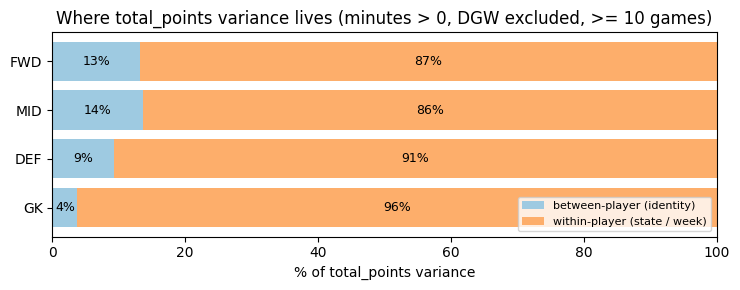

In [2]:
# min_appearances=10 matches the per-signal split so both describe one population.
ceil_rows = []
for p in POSITIONS:
    decomp = decompose_variance(df[df["position"] == p], value_col="total_points", group_col="player_id", min_appearances=10)
    ceil_rows.append({"position": p, **decomp})
ceil_tbl = pd.DataFrame(ceil_rows).set_index("position")
display(ceil_tbl[["n_players", "n_obs", "pct_between", "pct_within"]].round(1))

fig, ax = plt.subplots(figsize=(7.5, 3.0))
pct_btw, pct_wth = ceil_tbl["pct_between"], ceil_tbl["pct_within"]
ax.barh(ceil_tbl.index, pct_btw, color="#9ecae1", label="between-player (identity)")
ax.barh(ceil_tbl.index, pct_wth, left=pct_btw, color="#fdae6b", label="within-player (state / week)")
for i, p in enumerate(ceil_tbl.index):
    ax.text(pct_btw[p] / 2, i, f"{pct_btw[p]:.0f}%", va="center", ha="center", fontsize=9)
    ax.text(pct_btw[p] + pct_wth[p] / 2, i, f"{pct_wth[p]:.0f}%", va="center", ha="center", fontsize=9)
ax.set_xlim(0, 100)
ax.set_xlabel("% of total_points variance")
ax.set_title("Where total_points variance lives (minutes > 0, DGW excluded, >= 10 games)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

**Read:** a longer within-player (orange) segment means more week-to-week movement was observed for that position this season. A near-all-between (blue) bar means weekly points were driven mostly by stable level differences between players.

This is a **descriptive split, not a verdict on any stat**. The next question (`identity_vs_state.ipynb`) takes each live signal and asks whether *its* link to points runs through between-player or within-player structure — read against the movement this chart describes.

> *Scale note:* this is a between/within sum-of-squares partition (descriptive, level-based squared); the per-signal split is rank-based (Spearman). The two are complementary framings — a descriptive reference, not a number-to-number comparison with `within_share`.